# 4-model comparison: RF-DETR (arcade_trainval, dataset2_augs, arcade_sl) + YOLOv9c arcade

Evaluated on `cadica_50plus_new` (2215 images, 3089 GT) and `dataset2_split_test` (1252 images, 1252 GT).

In [41]:
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
from pathlib import Path
from PIL import Image
from collections import defaultdict
from torchmetrics.detection import MeanAveragePrecision
from torchvision.ops import box_iou

ROOT = Path('/home/dsa/stenosis')
IMG_DIR = ROOT / 'data' / 'cadica_50plus_new' / 'images'
LBL_DIR = ROOT / 'data' / 'cadica_50plus_new' / 'labels'

CONF = 0.25
CENTRAL_RATIO = 0.15
FRAMES_PER_SEQ = 2

# Model configs: (short_name, eval_dir, color)
MODELS = {
    'RFDETR arcade_tv': {
        'dir': ROOT / 'rfdetr_runs' / 'arcade_dataset2_trainval',
        'color': '#2196F3',
    },
    'RFDETR d2_augs': {
        'dir': ROOT / 'rfdetr_runs' / 'dataset2_augs',
        'color': '#FF9800',
    },
    'RFDETR arcade_sl': {
        'dir': ROOT / 'rfdetr_runs' / 'arcade_singlelabel',
        'color': '#9C27B0',
    },
    'YOLOv9c arcade': {
        'dir': ROOT / 'yolo' / 'yolov9' / 'runs' / 'train' / 'arcade_yolov9c',
        'color': '#4CAF50',
        'suffix': '_singlecls',
    },
}

## 1. Load all metrics

In [42]:
metrics_c1 = {}  # cadica_50plus_new
metrics_c2 = {}  # dataset2_split_test
preds_c1 = {}    # cadica preds
preds_c2 = {}    # dataset2 preds

for name, cfg in MODELS.items():
    sfx = cfg.get('suffix', '')
    with open(cfg['dir'] / f'eval_cadica_50plus_new{sfx}.json') as f:
        metrics_c1[name] = json.load(f)
    with open(cfg['dir'] / f'eval_dataset2_split_test{sfx}.json') as f:
        metrics_c2[name] = json.load(f)
    with open(cfg['dir'] / f'preds_cadica_50plus_new{sfx}.json') as f:
        preds_c1[name] = json.load(f)
    with open(cfg['dir'] / f'preds_dataset2_split_test{sfx}.json') as f:
        preds_c2[name] = json.load(f)
    print(f'{name}: loaded')

print(f'\nLoaded {len(MODELS)} models')

RFDETR arcade_tv: loaded
RFDETR d2_augs: loaded
RFDETR arcade_sl: loaded
YOLOv9c arcade: loaded

Loaded 4 models


In [43]:
seq_re = re.compile(r'^(p\d+_v\d+)_(\d+)\.png$')

def read_yolo_boxes(lbl_path, w, h):
    boxes = []
    if not lbl_path.exists() or lbl_path.stat().st_size == 0:
        return boxes
    for line in lbl_path.read_text().strip().splitlines():
        parts = line.split()
        if len(parts) < 5:
            continue
        cx, cy, bw, bh = map(float, parts[1:5])
        boxes.append([
            (cx - bw / 2) * w, (cy - bh / 2) * h,
            (cx + bw / 2) * w, (cy + bh / 2) * h,
        ])
    return boxes

def build_cadica_sequences(img_dir):
    sequences = defaultdict(list)
    for p in sorted(img_dir.glob('*.png')):
        match = seq_re.match(p.name)
        if not match:
            continue
        seq_id = match.group(1)
        frame_idx = int(match.group(2))
        sequences[seq_id].append((frame_idx, p))
    return {seq_id: [p for _, p in sorted(items)] for seq_id, items in sequences.items()}

def select_central_paths(paths, ratio=CENTRAL_RATIO):
    n = len(paths)
    if n <= 2:
        return []
    count = max(1, round(n * ratio))
    count = min(count, n - 2)
    start = (n - count) // 2
    start = max(1, min(start, n - count - 1))
    end = start + count
    return paths[start:end]

def build_targets(image_paths, lbl_dir):
    targets = []
    for p in image_paths:
        with Image.open(p) as img_pil:
            w, h = img_pil.size
        gt = read_yolo_boxes(lbl_dir / f'{p.stem}.txt', w, h)
        targets.append({
            'boxes': torch.tensor(gt, dtype=torch.float32) if gt else torch.zeros((0, 4), dtype=torch.float32),
            'labels': torch.zeros(len(gt), dtype=torch.long),
        })
    return targets

def build_preds(image_paths, raw_preds):
    preds = []
    for p in image_paths:
        entry = raw_preds.get(p.name, {})
        boxes = entry.get('boxes', [])
        scores = entry.get('scores', [])
        preds.append({
            'boxes': torch.tensor(boxes, dtype=torch.float32) if boxes else torch.zeros((0, 4), dtype=torch.float32),
            'scores': torch.tensor(scores, dtype=torch.float32) if scores else torch.zeros(0, dtype=torch.float32),
            'labels': torch.zeros(len(scores), dtype=torch.long),
        })
    return preds

def compute_metrics(targets_list, preds_list, conf_thresh=CONF):
    results = {}

    for iou_thresh in [0.25, 0.50]:
        metric = MeanAveragePrecision(iou_thresholds=[iou_thresh])
        metric.update(preds_list, targets_list)
        values = metric.compute()
        results[f'mAP@{iou_thresh}'] = round(values['map'].item(), 4)
        results[f'mAR@{iou_thresh}'] = round(values['mar_100'].item(), 4)

    for iou_thresh in [0.25, 0.3, 0.5]:
        total_gt = 0
        matched_gt = 0
        total_fp = 0
        for target, pred in zip(targets_list, preds_list):
            gt_boxes = target['boxes']
            mask = pred['scores'] >= conf_thresh
            pred_boxes = pred['boxes'][mask]
            if len(gt_boxes) > 0:
                total_gt += len(gt_boxes)
                if len(pred_boxes) > 0:
                    iou_matrix = box_iou(gt_boxes, pred_boxes)
                    max_iou_per_gt, _ = iou_matrix.max(dim=1)
                    matched_gt += (max_iou_per_gt >= iou_thresh).sum().item()
                    max_iou_per_pred, _ = iou_matrix.max(dim=0)
                    total_fp += (max_iou_per_pred < iou_thresh).sum().item()
            else:
                total_fp += len(pred_boxes)

        recall = matched_gt / total_gt if total_gt > 0 else 0.0
        precision = matched_gt / (matched_gt + total_fp) if (matched_gt + total_fp) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        results[f'recall@IoU{iou_thresh}_conf{conf_thresh}'] = round(recall, 4)
        results[f'precision@IoU{iou_thresh}_conf{conf_thresh}'] = round(precision, 4)
        results[f'f1@IoU{iou_thresh}_conf{conf_thresh}'] = round(f1, 4)
        results[f'matched_gt@IoU{iou_thresh}_conf{conf_thresh}'] = matched_gt

    results['total_gt'] = total_gt
    return results

cadica_sequences = build_cadica_sequences(IMG_DIR)
short_sequences = sum(1 for paths in cadica_sequences.values() if len(paths) <= 2)
cadica_central_sequences = {
    seq_id: select_central_paths(paths)
    for seq_id, paths in cadica_sequences.items()
}
cadica_eval_paths = [
    p
    for seq_id in sorted(cadica_central_sequences)
    for p in cadica_central_sequences[seq_id]
    if p is not None
]
cadica_eval_names = {p.name for p in cadica_eval_paths}
targets_c1_central = build_targets(cadica_eval_paths, LBL_DIR)

metrics_c1_central = {}
for name in MODELS:
    preds_list = build_preds(cadica_eval_paths, preds_c1[name])
    model_metrics = compute_metrics(targets_c1_central, preds_list)
    model_metrics['num_images'] = len(cadica_eval_paths)
    metrics_c1_central[name] = model_metrics

gt_positive_central = sum(
    1
    for p in cadica_eval_paths
    if (LBL_DIR / f'{p.stem}.txt').exists() and (LBL_DIR / f'{p.stem}.txt').stat().st_size > 0
)
selected_share = len(cadica_eval_paths) / sum(len(paths) for paths in cadica_sequences.values())

print(f'Sequences: {len(cadica_sequences)}')
print(f'Short sequences skipped (<= 2 frames): {short_sequences}')
print(f'Central subset: {len(cadica_eval_paths)} frames ({selected_share:.1%} of cadica_50plus_new)')
print(f'Central subset with GT: {gt_positive_central}')

/home/dsa/miniconda3/envs/stenosis/lib/python3.10/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)


Sequences: 160
Short sequences skipped (<= 2 frames): 8
Central subset: 336 frames (15.2% of cadica_50plus_new)
Central subset with GT: 330


## Central 25% evaluation subset — cadica_50plus_new

## Comparison table — cadica_50plus_new all frames

## 2. Comparison table — cadica_50plus_new central 25%

In [44]:
metric_keys = ['mAP@0.25', 'mAR@0.25', 'mAP@0.5', 'mAR@0.5']
for iou in [0.25, 0.3, 0.5]:
    for m in ['recall', 'precision', 'f1']:
        metric_keys.append(f'{m}@IoU{iou}_conf{CONF}')

rows = []
for key in metric_keys:
    row = {'Metric': key}
    for name in MODELS:
        v = metrics_c1_central[name].get(key, '-')
        row[name] = f'{v:.4f}' if isinstance(v, (int, float)) else str(v)
    rows.append(row)

df1 = pd.DataFrame(rows)
df1.style.set_properties(**{'text-align': 'right'}).set_properties(subset=['Metric'], **{'text-align': 'left'})

,Metric,RFDETR arcade_tv,RFDETR d2_augs,RFDETR arcade_sl,YOLOv9c arcade
0,mAP@0.25,0.3784,0.2857,0.4400,0.2944
1,mAR@0.25,0.9699,0.9376,0.8667,0.5269
2,mAP@0.5,0.1062,0.0554,0.0519,0.0198
3,mAR@0.5,0.7097,0.5054,0.3527,0.1247
4,recall@IoU0.25_conf0.25,0.4215,0.3806,0.4860,0.2753
5,precision@IoU0.25_conf0.25,0.4346,0.3491,0.4829,0.5792
6,f1@IoU0.25_conf0.25,0.4279,0.3642,0.4845,0.3732
7,recall@IoU0.3_conf0.25,0.3699,0.3462,0.4022,0.2129
8,precision@IoU0.3_conf0.25,0.3789,0.3114,0.3912,0.4480
9,f1@IoU0.3_conf0.25,0.3743,0.3279,0.3966,0.2886


## 3. Bar chart — cadica_50plus_new central 25%

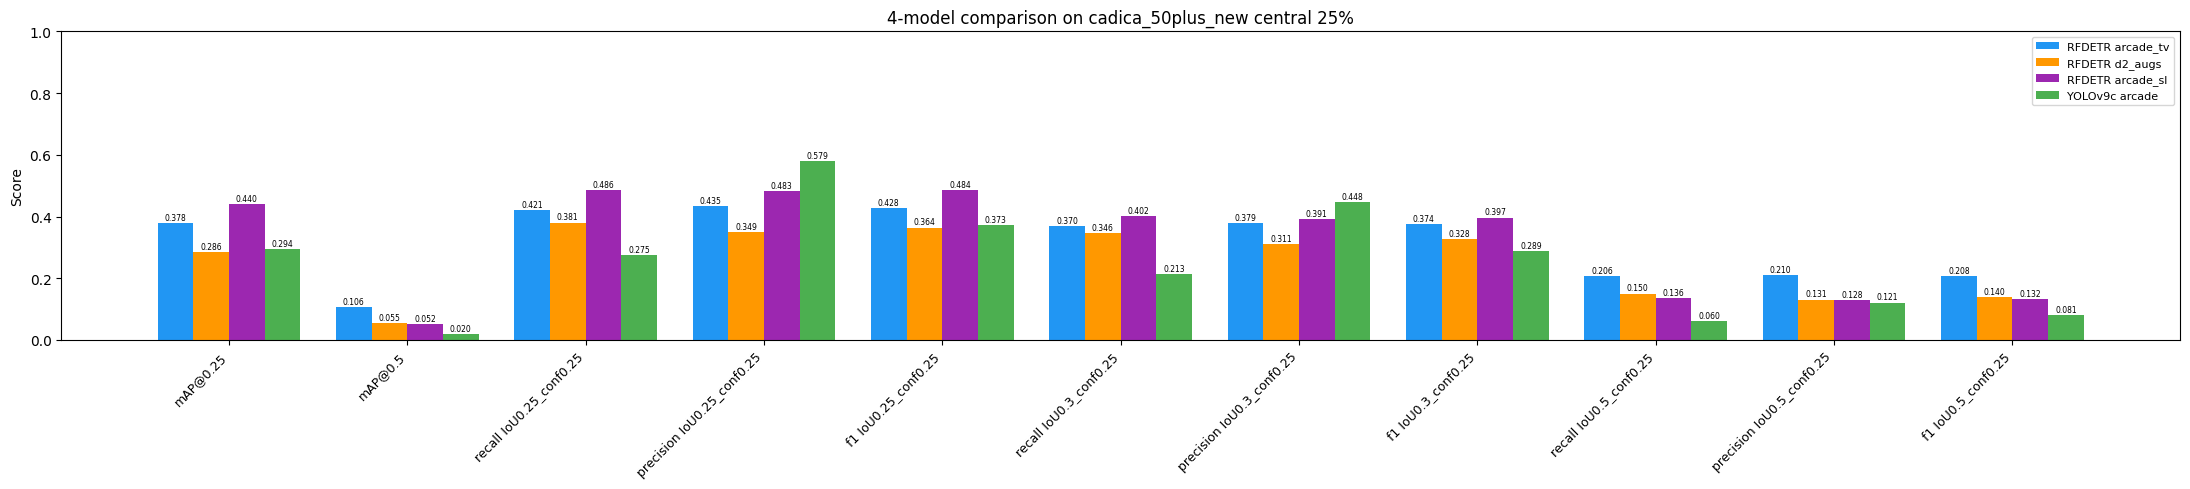

In [46]:
bar_keys = ['mAP@0.25', 'mAP@0.5']
for iou in [0.25, 0.3, 0.5]: 
    for m in ['recall', 'precision', 'f1']:
        bar_keys.append(f'{m}@IoU{iou}_conf{CONF}')

n_models = len(MODELS)
x = np.arange(len(bar_keys))
w = 0.8 / n_models

fig, ax = plt.subplots(figsize=(22, 5))
for j, (name, cfg) in enumerate(MODELS.items()):
    vals = [metrics_c1_central[name].get(k, 0) for k in bar_keys]
    offset = (j - (n_models - 1) / 2) * w
    bars = ax.bar(x + offset, vals, w, label=name, color=cfg['color'])
    for i, v in enumerate(vals):
        ax.text(x[i] + offset, v + 0.01, f'{v:.3f}', ha='center', fontsize=5.5)

short_labels = [k.replace('_conf0.15', '').replace('@IoU', ' IoU') for k in bar_keys]
ax.set_xticks(x)
ax.set_xticklabels(short_labels, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Score')
ax.set_title('4-model comparison on cadica_50plus_new central 25%')
ax.legend(fontsize=8)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## 4. Comparison table — dataset2_split_test

In [47]:
rows2 = []
for key in metric_keys:
    row = {'Metric': key}
    for name in MODELS:
        v = metrics_c2[name].get(key, '-')
        row[name] = f'{v:.4f}' if isinstance(v, (int, float)) else str(v)
    rows2.append(row)

df2 = pd.DataFrame(rows2)
df2.style.set_properties(**{'text-align': 'right'}).set_properties(subset=['Metric'], **{'text-align': 'left'})

,Metric,RFDETR arcade_tv,RFDETR d2_augs,RFDETR arcade_sl,YOLOv9c arcade
0,mAP@0.25,0.5459,0.4973,0.0683,0.0680
1,mAR@0.25,0.9808,0.9880,0.7165,0.3003
2,mAP@0.5,0.2083,0.2044,0.0010,0.0006
3,mAR@0.5,0.7284,0.6941,0.1558,0.0264
4,recall@IoU0.25_conf0.25,-,-,-,-
5,precision@IoU0.25_conf0.25,-,-,-,-
6,f1@IoU0.25_conf0.25,-,-,-,-
7,recall@IoU0.3_conf0.25,-,-,-,-
8,precision@IoU0.3_conf0.25,-,-,-,-
9,f1@IoU0.3_conf0.25,-,-,-,-


## 5. Bar chart — dataset2_split_test

In [ ]:
fig, ax = plt.subplots(figsize=(22, 5))
for j, (name, cfg) in enumerate(MODELS.items()):
    vals = [metrics_c2[name].get(k, 0) for k in bar_keys]
    offset = (j - (n_models - 1) / 2) * w
    ax.bar(x + offset, vals, w, label=name, color=cfg['color'])
    for i, v in enumerate(vals):
        ax.text(x[i] + offset, v + 0.01, f'{v:.3f}', ha='center', fontsize=5.5)

ax.set_xticks(x)
ax.set_xticklabels(short_labels, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Score')
ax.set_title('5-model comparison on dataset2_split_test')
ax.legend(fontsize=8)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## 6. Helper functions

In [ ]:
def read_yolo_boxes(lbl_path, w, h):
    boxes = []
    if not lbl_path.exists() or lbl_path.stat().st_size == 0:
        return boxes
    for line in lbl_path.read_text().strip().splitlines():
        parts = line.split()
        if len(parts) < 5: continue
        cx, cy, bw, bh = map(float, parts[1:5])
        boxes.append(((cx - bw/2)*w, (cy - bh/2)*h, (cx + bw/2)*w, (cy + bh/2)*h))
    return boxes

def draw_rects(ax, boxes, color, lw=2, show_conf=False):
    for b in boxes:
        if show_conf:
            x1, y1, x2, y2, conf = b
        else:
            x1, y1, x2, y2 = b
        ax.add_patch(patches.Rectangle((x1, y1), x2-x1, y2-y1, lw=lw, ec=color, fc='none'))
        if show_conf:
            ax.text(x1, y1-3, f'{conf:.2f}', color=color, fontsize=7,
                    bbox=dict(boxstyle='round,pad=0.1', fc='black', alpha=0.6))

def pred_to_boxes(pred_entry, thresh):
    if not pred_entry or not pred_entry.get('boxes'):
        return []
    out = []
    for (x1,y1,x2,y2), c in zip(pred_entry['boxes'], pred_entry['scores']):
        if c >= thresh:
            out.append((x1, y1, x2, y2, c))
    return out

## 7. Select cadica_50plus_new central frames

In [ ]:
selected = []
for sid in sorted(cadica_central_sequences):
    imgs = cadica_central_sequences[sid]
    imgs_with_gt = [
        p
        for p in imgs
        if (LBL_DIR / (p.stem + '.txt')).exists() and (LBL_DIR / (p.stem + '.txt')).stat().st_size > 0
    ]
    if not imgs_with_gt:
        continue
    n = len(imgs_with_gt)
    idx = np.linspace(0, n - 1, min(FRAMES_PER_SEQ, n), dtype=int)
    selected.extend(imgs_with_gt[i] for i in idx)

print(
    f'{len(cadica_central_sequences)} sequences, '
    f'{len(cadica_eval_paths)} central frames, '
    f'{len(selected)} GT-positive frames selected for visualization'
 )

## 8. Visual comparison — 4 models on cadica_50plus_new central 25%

In [ ]:
model_names = list(MODELS.keys())
model_colors = [MODELS[n]['color'] for n in model_names]
n_cols = 2 + len(model_names)  # Raw + GT + models

for p in selected:
    img = np.array(Image.open(p))
    h, w = img.shape[:2]
    gt = read_yolo_boxes(LBL_DIR / (p.stem + '.txt'), w, h)
    model_preds = {}
    for name in model_names:
        model_preds[name] = pred_to_boxes(preds_c1[name].get(p.name, {}), CONF)

    fig, ax = plt.subplots(1, n_cols, figsize=(6 * n_cols, 6))
    titles = ['Raw', f'GT ({len(gt)})'] + [f'{name} ({len(model_preds[name])})' for name in model_names]
    for a, t in zip(ax, titles):
        a.imshow(img, cmap='gray'); a.set_title(t, fontsize=9); a.axis('off')

    draw_rects(ax[1], gt, 'lime')
    for j, (name, color) in enumerate(zip(model_names, model_colors)):
        draw_rects(ax[2 + j], gt, 'lime', lw=1)
        draw_rects(ax[2 + j], model_preds[name], color, show_conf=True)

    m = seq_re.match(p.name)
    fig.suptitle(f'{m.group(1)} — {p.name}', fontsize=12, y=1.02)
    plt.tight_layout(); plt.show()

## 9. Select dataset2_split_test frames

In [ ]:
IMG_DIR2 = ROOT / 'data' / 'dataset2_split' / 'test' / 'images'
LBL_DIR2 = ROOT / 'data' / 'dataset2_split' / 'test' / 'labels'

all_test_imgs = sorted(IMG_DIR2.glob('*.jpg'))
imgs_with_gt2 = [p for p in all_test_imgs if (LBL_DIR2 / (p.stem + '.txt')).exists() and (LBL_DIR2 / (p.stem + '.txt')).stat().st_size > 0]
n2 = len(imgs_with_gt2)
idx2 = np.linspace(0, n2 - 1, min(20, n2), dtype=int)
selected2 = [imgs_with_gt2[i] for i in idx2]
print(f'{n2} images with GT, {len(selected2)} selected for visualization')

## 10. Visual comparison — 5 models on dataset2_split_test

In [ ]:
for p in selected2:
    img = np.array(Image.open(p))
    h, w = img.shape[:2]
    gt = read_yolo_boxes(LBL_DIR2 / (p.stem + '.txt'), w, h)
    model_preds = {}
    for name in model_names:
        model_preds[name] = pred_to_boxes(preds_c2[name].get(p.name, {}), CONF)

    fig, ax = plt.subplots(1, n_cols, figsize=(6 * n_cols, 6))
    titles = ['Raw', f'GT ({len(gt)})'] + [f'{name} ({len(model_preds[name])})' for name in model_names]
    for a, t in zip(ax, titles):
        a.imshow(img, cmap='gray'); a.set_title(t, fontsize=9); a.axis('off')

    draw_rects(ax[1], gt, 'lime')
    for j, (name, color) in enumerate(zip(model_names, model_colors)):
        draw_rects(ax[2 + j], gt, 'lime', lw=1)
        draw_rects(ax[2 + j], model_preds[name], color, show_conf=True)

    fig.suptitle(p.name, fontsize=12, y=1.02)
    plt.tight_layout(); plt.show()